# Etude de cas : SP3H

## 1 Requête pour retrouver l’entreprise dans PATSTAT

In [ ]:
SELECT person_id, person_name, person_address, doc_std_name
FROM tls206_person
WHERE person_name LIKE 'SP3H%';

## 2 Extraction du portefeuille de brevets

In [ ]:
SELECT count(pa.appln_id)
FROM tls207_pers_appln pa
JOIN tls206_person p ON pa.person_id = p.person_id
WHERE p.person_name LIKE 'SP3H'
  AND pa.applt_seq_nr > 0;   -- applicant, pas inventeur
  

99 demndes de brevet depose par l'entrerise

## 3 Obtenir la table centrale des demandes

In [ ]:
SELECT *
FROM tls201_appln
WHERE appln_id IN (
    SELECT appln_id
    FROM tls207_pers_appln pa
    JOIN tls206_person p ON pa.person_id = p.person_id
    WHERE p.person_name LIKE 'SP3H%'
      AND pa.applt_seq_nr > 0
);

In [ ]:
import pandas as pd

table_centrale=pd.read_csv("Data/Table centrale des demandes.csv", sep=";")

# Conversion des dates 
table_centrale["appln_filing_date"] = pd.to_datetime(table_centrale["appln_filing_date"], errors="coerce")
table_centrale["year"] = table_centrale["appln_filing_date"].dt.year # type: ignore

table_centrale

,appln_id,appln_auth,appln_nr,appln_kind,appln_filing_date,appln_filing_year,appln_nr_epodoc,appln_nr_original,ipr_type,receiving_office,...,earliest_publn_year,earliest_pat_publn_id,granted,docdb_family_id,inpadoc_family_id,docdb_family_size,nb_citing_docdb_fam,nb_applicants,nb_inventors,year
0,19119810,FR,0655506,A,2006-12-14,2006,FR20060055506,0655506,PI,,...,2008,277662206,Y,37890311,49366,6,7,1,4,2006
1,445741356,KR,20157017680,A,2013-12-04,2013,KR20157017680,1020157017680,PI,,...,2015,445741357,N,49886962,381150530,16,2,1,2,2013
2,57222421,EP,08845379,A,2008-08-14,2008,EP20080845379,08845379,PI,,...,2010,320935526,Y,39186988,19125835,12,13,1,2,2008
3,413979607,WO,2013052940,W,2013-12-04,2013,WO2013FR52940,FR2013/052940,PI,FR,...,2014,418885617,N,49886962,381150530,16,2,1,2,2013
4,422225201,JP,2014087423,A,2014-04-21,2014,JP20140087423,2014087423,PI,,...,2014,421493435,N,37890311,49366,6,7,1,4,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,449672078,MX,2015007174,A,2013-12-04,2013,MX20150007174,2015007174,PI,,...,2015,449672079,Y,49886962,381150530,16,2,1,2,2013
95,273550282,AU,2008263740,A,2008-05-07,2008,AU20080263740,2008263740,PI,,...,2008,276981743,Y,38820234,19130688,12,10,1,2,2008
96,56224356,EP,07823392,A,2007-08-02,2007,EP20070823392,07823392,PI,,...,2009,278806188,Y,37663186,19110797,12,15,1,2,2007
97,322434300,CN,200880111172,A,2008-09-26,2008,CN200880111172,200880111172,PI,,...,2010,324033162,N,39267773,19126659,12,27,1,3,2008


### Dynamique de l’innovation (évolution dans le temps)


#### volet 1 - quantite

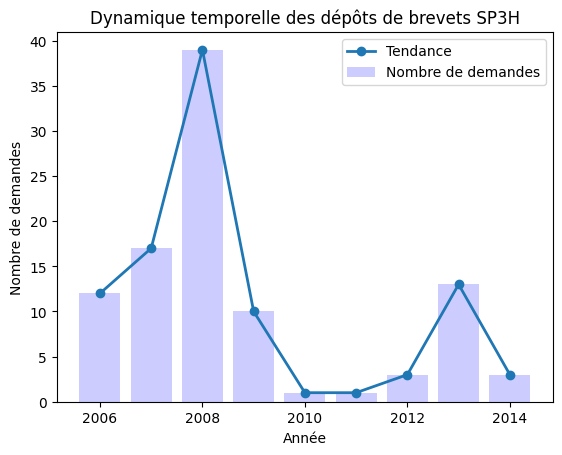

In [24]:
import matplotlib.pyplot as plt

depot_par_annee = (
    table_centrale.groupby("year")
    .size()
    .reset_index(name="nb_demandes")
    .dropna()
)

plt.figure()

# Bar plot (volume annuel)
plt.bar(
    depot_par_annee["year"],
    depot_par_annee["nb_demandes"],
    color="blue",
    alpha=0.2,
    label="Nombre de demandes"
)

# Line plot (tendance)
plt.plot(
    depot_par_annee["year"],
    depot_par_annee["nb_demandes"],
    marker="o",
    linewidth=2,
    label="Tendance"
)

plt.xlabel("Année")
plt.ylabel("Nombre de demandes")
plt.title("Dynamique temporelle des dépôts de brevets SP3H")
plt.legend()

plt.show()

ou

In [ ]:
SELECT YEAR(appln_filing_date) AS year, COUNT(*) AS nb_applns
FROM tls201_appln
WHERE appln_id IN (SELECT pa.appln_id
FROM tls207_pers_appln pa
JOIN tls206_person p ON pa.person_id = p.person_id
WHERE p.person_name LIKE 'SP3H'
  AND pa.applt_seq_nr > 0)  -- applicant, pas inventeur
GROUP BY YEAR(appln_filing_date)
ORDER BY year;

#### volet 2 - qualite

In [ ]:
table_centrale["granted"]=(table_centrale["granted"].astype(str).str.strip().str.upper()
        .map({"Y": 1, "N": 0}))

#  Normaliser la colonne (accepte 1/0, True/False, 'Y'/'N', etc.)
s = table_centrale["granted"]


# 3) Calculer le taux de brevets accordés
valid = s.dropna()
n_total = len(valid)
n_granted = int((valid == 1).sum())
pct_granted = 100 * n_granted / n_total if n_total > 0 else 0.0


print(f"Nombre accordés (granted=1): {n_granted} ({pct_granted:.1f}%)")


Nombre accordés (granted=1): 64 (64.6%)


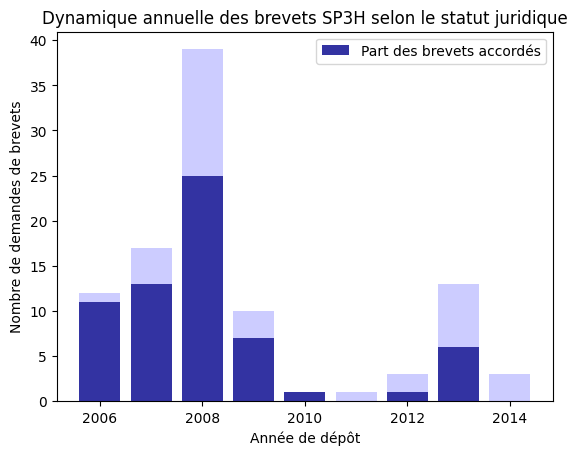

In [35]:
import matplotlib.pyplot as plt
granted_by_year = (
    table_centrale.groupby("year")
      .agg(
          nb_demandes=("granted", "count"),
          nb_granted=("granted", "sum")
      )
      .reset_index()
)

granted_by_year["taux_granted"] = (
    100 * granted_by_year["nb_granted"] / granted_by_year["nb_demandes"]
)

# Données
years = granted_by_year["year"]
nb_granted = granted_by_year["nb_granted"]
nb_not_granted = granted_by_year["nb_demandes"] - granted_by_year["nb_granted"]

plt.figure()

# Partie accordée
plt.bar(
    years,
    nb_granted,
    color="darkblue",
    alpha=0.8,
    label="Part des brevets accordés"
)

# Partie non accordée
plt.bar(
    years,
    nb_not_granted,
    color="blue",
    alpha=0.2,
    bottom=nb_granted,
)

plt.xlabel("Année de dépôt")
plt.ylabel("Nombre de demandes de brevets")
plt.title("Dynamique annuelle des brevets SP3H selon le statut juridique")
plt.legend()

plt.show()

## 4 Marchés géographiques visés

###  Pays / offices de dépôt

In [ ]:
SELECT appln_auth, COUNT(*) AS nb
FROM tls201_appln
WHERE appln_id IN (SELECT pa.appln_id
FROM tls207_pers_appln pa
JOIN tls206_person p ON pa.person_id = p.person_id
WHERE p.person_name LIKE 'SP3H%'
  AND pa.applt_seq_nr > 0)
GROUP BY appln_auth;

ou

In [36]:
table_centrale

,appln_id,appln_auth,appln_nr,appln_kind,appln_filing_date,appln_filing_year,appln_nr_epodoc,appln_nr_original,ipr_type,receiving_office,...,earliest_publn_year,earliest_pat_publn_id,granted,docdb_family_id,inpadoc_family_id,docdb_family_size,nb_citing_docdb_fam,nb_applicants,nb_inventors,year
0,19119810,FR,0655506,A,2006-12-14,2006,FR20060055506,0655506,PI,,...,2008,277662206,1,37890311,49366,6,7,1,4,2006
1,445741356,KR,20157017680,A,2013-12-04,2013,KR20157017680,1020157017680,PI,,...,2015,445741357,0,49886962,381150530,16,2,1,2,2013
2,57222421,EP,08845379,A,2008-08-14,2008,EP20080845379,08845379,PI,,...,2010,320935526,1,39186988,19125835,12,13,1,2,2008
3,413979607,WO,2013052940,W,2013-12-04,2013,WO2013FR52940,FR2013/052940,PI,FR,...,2014,418885617,0,49886962,381150530,16,2,1,2,2013
4,422225201,JP,2014087423,A,2014-04-21,2014,JP20140087423,2014087423,PI,,...,2014,421493435,0,37890311,49366,6,7,1,4,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,449672078,MX,2015007174,A,2013-12-04,2013,MX20150007174,2015007174,PI,,...,2015,449672079,1,49886962,381150530,16,2,1,2,2013
95,273550282,AU,2008263740,A,2008-05-07,2008,AU20080263740,2008263740,PI,,...,2008,276981743,1,38820234,19130688,12,10,1,2,2008
96,56224356,EP,07823392,A,2007-08-02,2007,EP20070823392,07823392,PI,,...,2009,278806188,1,37663186,19110797,12,15,1,2,2007
97,322434300,CN,200880111172,A,2008-09-26,2008,CN200880111172,200880111172,PI,,...,2010,324033162,0,39267773,19126659,12,27,1,3,2008


   office  nb_demandes
0      WO           12
1      EP           11
2      FR           10
3      US            9
4      BR            9
5      CN            8
6      KR            7
7      MX            5
8      CA            5
9      ES            4
10     AU            4
11     JP            3
12     PL            2
13     RU            2
14     MY            2
15     AT            2
16     DE            2
17     GB            1
18     UA            1


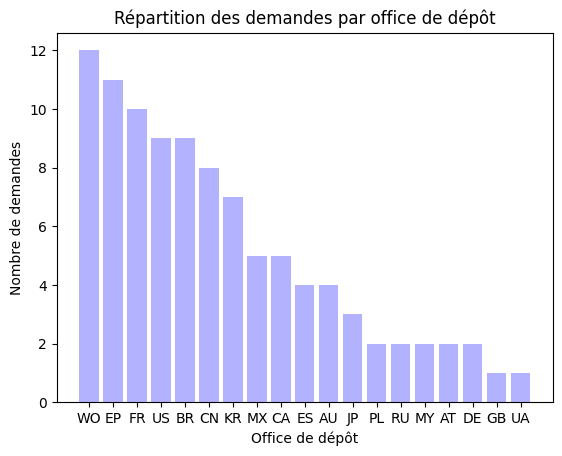

In [93]:
if "appln_auth" in table_centrale.columns:
    depots_par_office = (
        table_centrale["appln_auth"]
        .value_counts()
        .reset_index()
        .rename(columns={"appln_auth": "office", "count": "nb_demandes"})
    )

    print(depots_par_office)

    plt.figure()
    plt.bar(depots_par_office["office"], depots_par_office["nb_demandes"], color="blue", alpha=0.3)
    plt.xlabel("Office de dépôt")
    plt.ylabel("Nombre de demandes")
    plt.title("Répartition des demandes par office de dépôt")
    plt.show()

### Pays de publication (où SP3H cherche à protéger)

In [ ]:
SELECT pb.publn_auth, COUNT(DISTINCT pb.appln_id) AS nb
FROM tls211_pat_publn pb
WHERE pb.appln_id IN (SELECT pa.appln_id
FROM tls207_pers_appln pa
JOIN tls206_person p ON pa.person_id = p.person_id
WHERE p.person_name LIKE 'SP3H%'
  AND pa.applt_seq_nr > 0)
GROUP BY pb.publn_auth;

In [ ]:
publication_par_office=pd.read_csv("Data/Pays de publication.csv", sep=';')
publication_par_office = publication_par_office.rename(columns={"publn_auth": "office", "nb": "nb_publications"})
publication_par_office = (
    publication_par_office
    .sort_values("nb_publications", ascending=False)
    .reset_index(drop=True)
)
publication_par_office

,office,nb_publications
0,WO,12
1,EP,11
2,FR,10
3,BR,9
4,US,9
5,CN,8
6,KR,7
7,CA,5
8,MX,5
9,ES,4


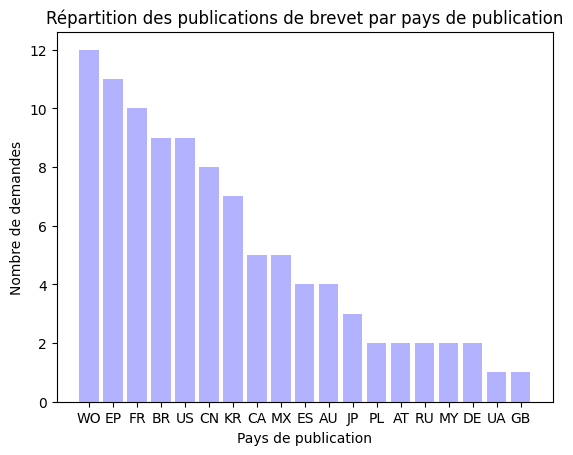

In [ ]:
plt.figure()
plt.bar(publication_par_office["office"], publication_par_office["nb_publications"], color="blue", alpha=0.3) # type: ignore
plt.xlabel("Pays de publication")
plt.ylabel("Nombre de demandes")
plt.title("Répartition des publications de brevet par pays de publication")
plt.show()



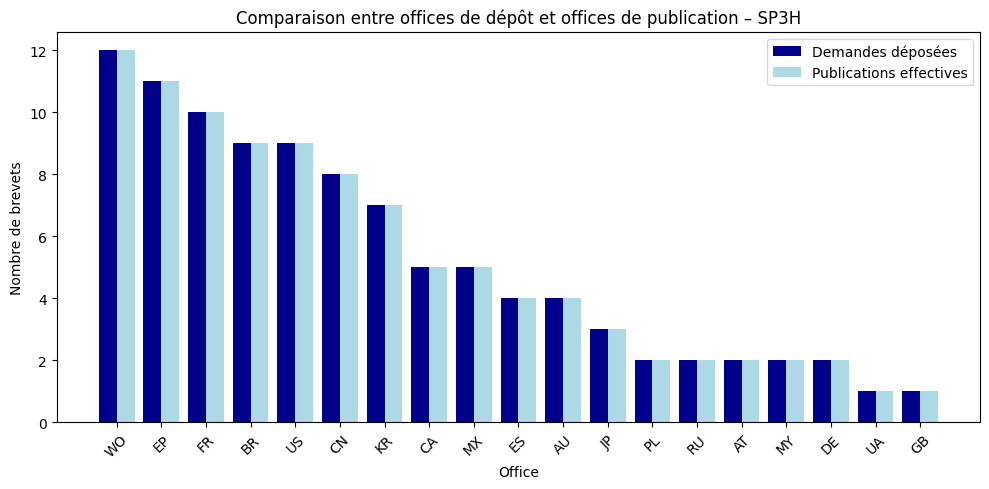

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_compare = depots_par_office.merge(# type: ignore
    publication_par_office, # type: ignore
    on="office",
    how="outer"
).fillna(0) 

df_compare = df_compare.sort_values("nb_demandes", ascending=False)

plt.figure(figsize=(10, 5))

x = range(len(df_compare))

plt.bar(
    x,
    df_compare["nb_demandes"],
    width=0.4,
    color="darkblue",
    label="Demandes déposées"
)

plt.bar(
    [i + 0.4 for i in x],
    df_compare["nb_publications"],
    width=0.4,
    color="lightblue",
    label="Publications effectives"
)

plt.xticks(
    [i + 0.2 for i in x],
    df_compare["office"],
    rotation=45
)

plt.xlabel("Office")
plt.ylabel("Nombre de brevets")
plt.title("Comparaison entre offices de dépôt et offices de publication – SP3H")
plt.legend()
plt.tight_layout()
plt.show()

### Taille des familles DOCDB (mesure de l’internationalisation)

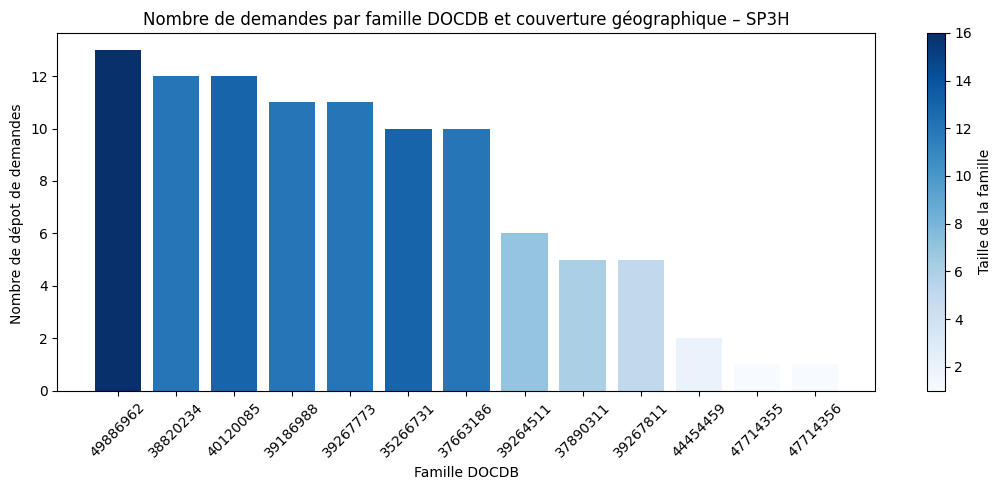

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Agrégation par famille
taille_familles = (
    table_centrale
    .groupby("docdb_family_id")
    .agg(
        nb_demandes=("docdb_family_id", "size"),
        pays_couvert=("docdb_family_size", "first")
    )
    .reset_index()
)

taille_familles_sorted = taille_familles.sort_values(
    "nb_demandes", ascending=False
)

# Normalisation des couleurs
norm = mpl.colors.Normalize(# type: ignore
    vmin=taille_familles_sorted["pays_couvert"].min(),
    vmax=taille_familles_sorted["pays_couvert"].max()
) # type: ignore
cmap = plt.cm.Blues # type: ignore
colors = cmap(norm(taille_familles_sorted["pays_couvert"]))

# Création explicite figure + axe
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    taille_familles_sorted["docdb_family_id"].astype(str),
    taille_familles_sorted["nb_demandes"],
    color=colors
)

ax.set_xlabel("Famille DOCDB")
ax.set_ylabel("Nombre de dépot de demandes ")
ax.set_title("Nombre de demandes par famille DOCDB et couverture géographique – SP3H")
ax.tick_params(axis="x", rotation=45)

# Colorbar correctement attachée à l’axe
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap) # type: ignore
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Taille de la famille")

plt.tight_layout()
plt.show()

ou

In [ ]:
SELECT
    t1.docdb_family_id,
    t1.docdb_family_size,
    COUNT(DISTINCT t1.appln_id)  AS nb_brevets_sp3h
FROM tls201_appln t1
JOIN tls211_pat_publn t2
    ON t1.appln_id = t2.appln_id
JOIN tls207_pers_appln pa
    ON t1.appln_id = pa.appln_id
JOIN tls206_person p
    ON pa.person_id = p.person_id
WHERE p.person_name LIKE 'SP3H%'
  AND pa.applt_seq_nr > 0
GROUP BY t1.docdb_family_id,t1.docdb_family_size
ORDER BY nb_brevets_sp3h DESC;



## 5. Diversité technologique (IPC/techn_field)

#### IPC (classification internationale)

In [ ]:
SELECT ipc_class_symbol, COUNT(DISTINCT appln_id) AS nb
FROM tls209_appln_ipc
WHERE appln_id IN (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H%'
          AND pa.applt_seq_nr > 0
    )
GROUP BY ipc_class_symbol
ORDER BY nb DESC;

In [95]:
diversite=pd.read_csv("Data/Diversité technologique.csv", sep=";")
diversite

,ipc_class_symbol,nb
0,G01N 21/35,39
1,G01N 21/85,26
2,F02D 41/24,22
3,G01J 3/10,21
4,F02D 41/00,19
...,...,...
58,G01J 1/00,1
59,F02M 51/04,1
60,G02B 6/42,1
61,F02D 41/26,1


Nombre de classes IPC distinctes : 63


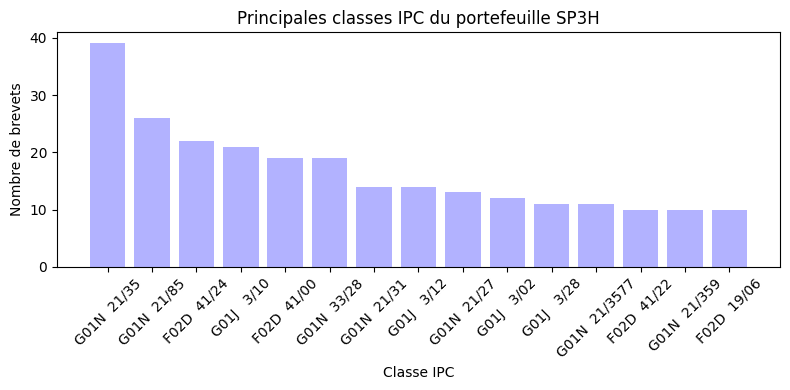

In [104]:
nb_ipc = diversite["ipc_class_symbol"].nunique()
print(f"Nombre de classes IPC distinctes : {nb_ipc}")

import matplotlib.pyplot as plt

top_n = 15
top_ipc = diversite.head(top_n)

plt.figure(figsize=(8,4))
plt.bar(top_ipc["ipc_class_symbol"], top_ipc["nb"], color="blue", alpha=0.3)
plt.xlabel("Classe IPC")
plt.ylabel("Nombre de brevets")
plt.title("Principales classes IPC du portefeuille SP3H")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Agrégation en grands domaines technologiques

In [ ]:
SELECT *
FROM tls230_appln_techn_field
WHERE appln_id IN (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H%'
          AND pa.applt_seq_nr > 0
    )


In [107]:
domaine=pd.read_csv("Data/Domaines technologiques.csv",sep=";")
domaine

,appln_id,techn_field_nr,weight
0,381150532,1,1.000000
1,405962392,10,0.666667
2,405962392,11,0.333333
3,425016237,8,0.222222
4,425016237,9,0.444444
...,...,...,...
154,275342726,11,0.111111
155,275342726,27,0.555556
156,414070038,10,1.000000
157,19126659,10,0.666667


In [117]:
domain_counts = (
    domaine
    .groupby("techn_field_nr", as_index=False)
    .agg(
        Nombre_de_brevets=("techn_field_nr", "count"),
        Poids_total=("weight", "sum")
    )
    .rename(columns={
        "techn_field_nr": "Domaine technologique"
    })
    .sort_values("Poids_total", ascending=False)
)

domain_counts

,Domaine technologique,Nombre_de_brevets,Poids_total
4,10,83,57.984127
7,27,44,28.437302
5,11,22,6.322222
0,1,2,2.000000
3,9,2,0.694444
2,8,2,0.650794
8,32,1,0.500000
1,6,2,0.300000
6,24,1,0.111111


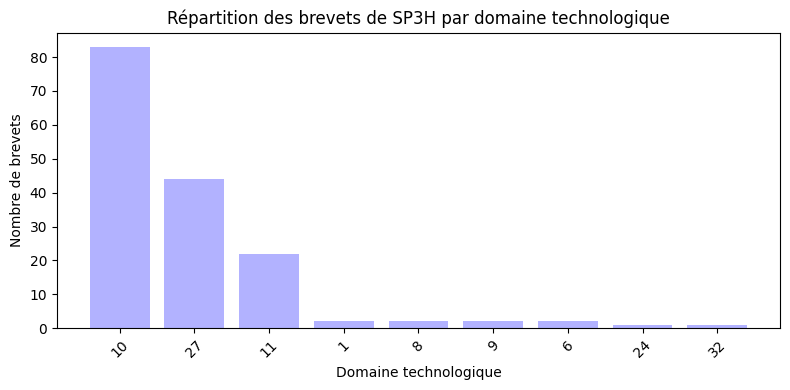

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(
    domain_counts["Domaine technologique"].astype(str),
    domain_counts["Nombre de brevets"],
    color="blue",
    alpha=0.3
)
plt.xlabel("Domaine technologique")
plt.ylabel("Nombre de brevets")
plt.title("Répartition des brevets de SP3H par domaine technologique")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

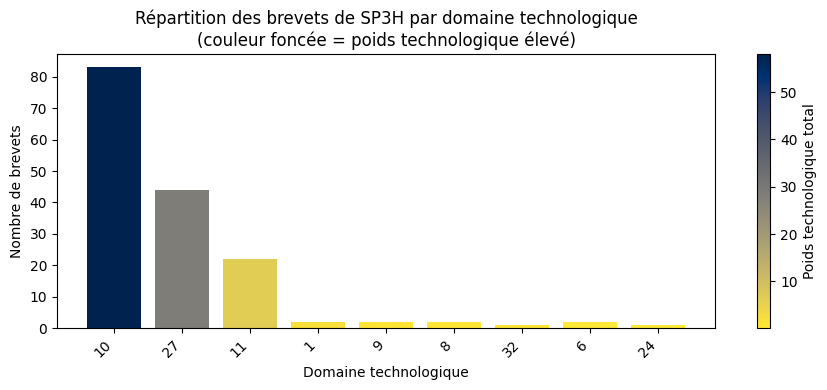

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

labels = domain_counts["Domaine technologique"].astype(str)
values = domain_counts["Nombre_de_brevets"]
weights = domain_counts["Poids_total"]

norm = mpl.colors.Normalize( # type: ignore
    vmin=weights.min(),
    vmax=weights.max()
)

cmap = plt.cm.cividis_r  # type: ignore 
colors = cmap(norm(weights))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))

ax.bar(x, values, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Domaine technologique")
ax.set_ylabel("Nombre de brevets")
ax.set_title(
    "Répartition des brevets de SP3H par domaine technologique\n"
    "(couleur foncée = poids technologique élevé)"
)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap) # type: ignore
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Poids technologique total")

plt.tight_layout()
plt.show()

## 6. Stratégies de coopération en R&D

Objectif : identifier les co-applicants.

In [ ]:
SELECT a.*, p.person_name
FROM tls207_pers_appln pa
JOIN tls206_person p ON pa.person_id = p.person_id
JOIN tls201_appln a ON pa.appln_id = a.appln_id
WHERE a.appln_id IN 
    (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H%'
          AND pa.applt_seq_nr > 0
    )
  AND pa.applt_seq_nr > 0
ORDER BY appln_id;

In [159]:
coop=pd.read_csv("Data/Coopération en R&D.csv", sep=";")


coop = coop.merge(
    coop.groupby('appln_id')['person_name']
        .nunique()
        .reset_index(name='nb_deposants'),
    on='appln_id'
)
coop = coop[coop['nb_deposants'] > 1]

print(f"Pourcentage de brevet avec un co-deposant: {round((len(np.unique(coop['appln_id']))/99)*100)}%")

coop

Pourcentage de brevet avec un co-deposant: 18%


,appln_id,appln_auth,appln_nr,appln_kind,appln_filing_date,appln_filing_year,appln_nr_epodoc,appln_nr_original,ipr_type,receiving_office,...,earliest_pat_publn_id,granted,docdb_family_id,inpadoc_family_id,docdb_family_size,nb_citing_docdb_fam,nb_applicants,nb_inventors,person_name,nb_deposants
0,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,49367,N,37890311,49366,6,7,5,4,"LUNATI, ALAIN",5
1,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,49367,N,37890311,49366,6,7,5,4,"FOURNEL, JOHAN",5
2,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,49367,N,37890311,49366,6,7,5,4,SP3H,5
3,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,49367,N,37890311,49366,6,7,5,4,"BITEAU, GUILLAUME",5
4,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,49367,N,37890311,49366,6,7,5,4,"GERGAUD, THIERRY",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,364517523,WO,2012062158,W,2012-06-22,2012,WO2012EP62158,EP2012/062158,PI,EP,...,379467148,N,44454459,336389954,2,1,4,2,SP3H,4
107,364517523,WO,2012062158,W,2012-06-22,2012,WO2012EP62158,EP2012/062158,PI,EP,...,379467148,N,44454459,336389954,2,1,4,2,"MADDALENA, SAM",4
108,374982845,US,98930809,A,2009-04-21,2009,US20090989308,12989308,PI,,...,375077880,Y,40120085,67829,13,13,3,2,"Lunati, Alain",3
109,374982845,US,98930809,A,2009-04-21,2009,US20090989308,12989308,PI,,...,375077880,Y,40120085,67829,13,13,3,2,"Fournel, Johan",3


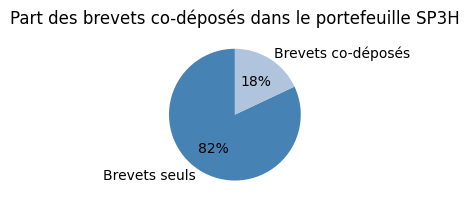

In [224]:
import matplotlib.pyplot as plt

labels = ["Brevets seuls", "Brevets co-déposés"]
values = [82, 18]  # en pourcentage

plt.figure(figsize=(3, 3))
plt.pie(
    values,
    labels=labels,
    autopct='%1.0f%%',
    startangle=90,
    colors = ["steelblue", "lightsteelblue"]
)
plt.title("Part des brevets co-déposés dans le portefeuille SP3H")
plt.tight_layout()
plt.show()

In [279]:
coopp = coop.drop(columns="person_name").drop_duplicates()
coopp

,appln_id,appln_auth,appln_nr,appln_kind,appln_filing_date,appln_filing_year,appln_nr_epodoc,appln_nr_original,ipr_type,receiving_office,...,earliest_publn_year,earliest_pat_publn_id,granted,docdb_family_id,inpadoc_family_id,docdb_family_size,nb_citing_docdb_fam,nb_applicants,nb_inventors,nb_deposants
0,49366,WO,2007002055,W,2007-12-12,2007,WO2007FR02055,FR2007/002055,PI,FR,...,2008,49367,N,37890311,49366,6,7,5,4,5
18,20934670,WO,2006000616,W,2006-03-21,2006,WO2006FR00616,FR2006/000616,PI,FR,...,2006,281047953,N,35266731,2744929,13,23,3,2,3
21,20939102,WO,2007001339,W,2007-08-02,2007,WO2007FR01339,FR2007/001339,PI,FR,...,2008,278806186,N,37663186,19110797,12,15,3,2,3
25,53978864,US,88437506,A,2006-03-21,2006,US20060884375,11884375,PI,,...,2008,281047960,Y,35266731,2744929,13,23,3,2,3
28,55179915,WO,2008000645,W,2008-05-07,2008,WO2008FR00645,FR2008/000645,PI,FR,...,2008,55563080,N,38820234,19130688,12,10,3,2,3
32,55754280,WO,2008002600,W,2008-09-30,2008,WO2008IB02600,IB2008/002600,PI,IB,...,2009,57162224,N,39267811,19126658,5,4,4,3,4
36,55758786,WO,2008002563,W,2008-09-26,2008,WO2008IB02563,IB2008/002563,PI,IB,...,2009,57162222,N,39267773,19126659,12,27,4,3,4
42,56626681,WO,2008001194,W,2008-08-14,2008,WO2008FR01194,FR2008/001194,PI,FR,...,2009,57348083,N,39186988,19125835,12,13,3,2,3
45,56840859,WO,2008002599,W,2008-09-30,2008,WO2008IB02599,IB2008/002599,PI,IB,...,2009,57162223,N,39264511,19126657,7,2,4,3,4
54,266971176,WO,2009000476,W,2009-04-21,2009,WO2009FR00476,FR2009/000476,PI,FR,...,2009,273549181,N,40120085,67829,13,13,3,2,3


In [164]:
coopp['appln_filing_year'].value_counts()

appln_filing_year
2008    7
2007    4
2006    2
2009    2
2010    1
2011    1
2012    1
Name: count, dtype: int64

In [ ]:
import pandas as pd

codeposants = [
    "BITEAU, GUILLAUME", "CHEN, JIAN", "FOURNEL, JOHAN",
    "GERGAUD, THIERRY", "LUNATI, ALAIN", "MADDALENA, SAM",
    "MELEXIS TESSENDERLO NV"
]

type_partenaire = {
    "MELEXIS TESSENDERLO NV": "Entreprise"
}

df_part = pd.DataFrame(codeposants, columns=["Nom"])
df_part["Type"] = df_part["Nom"].apply(
    lambda x: type_partenaire.get(x, "Personne physique")
)


part_counts = df_part["Type"].value_counts()
part_counts

Type
Personne physique    6
Entreprise           1
Name: count, dtype: int64

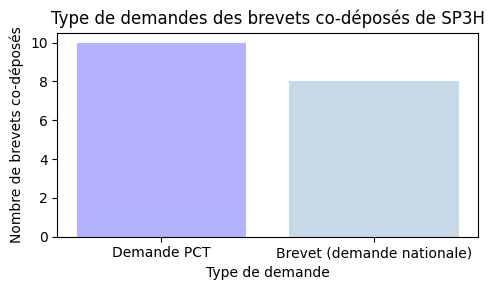

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Comptage par type de demande
appln_auth_counts = coopp['appln_kind'].value_counts()

# Mapping lisible

label_map = {
    'W': "Demande PCT",
    'A': "Brevet (demande nationale)"
}

# Création d’un DataFrame pour plus de contrôle
df_plot = (
    appln_auth_counts
    .rename_axis("appln_kind")
    .reset_index(name="Nombre")
)

df_plot["appln_kind"] = (
    df_plot["appln_kind"]
    .astype(str)
    .str.strip()
    .str.upper()
)
df_plot["Type de demande"] = df_plot["appln_kind"].map(label_map)

# Plot
plt.figure(figsize=(5,3))
plt.bar(
    df_plot["Type de demande"],
    df_plot["Nombre"],
    color=["blue", "steelblue"],
    alpha=0.3,
)

plt.xlabel("Type de demande")
plt.ylabel("Nombre de brevets co-déposés")
plt.title("Type de demandes des brevets co-déposés de SP3H")
plt.tight_layout()
plt.show()

appln_auth_counts = coopp['appln_auth'].value_counts()
plt.figure(figsize=(4,4))
plt.bar(appln_auth_counts.index, appln_auth_counts.values, color="blue", alpha=0.3) # type: ignore
plt.xlabel("Office de dépôt")
plt.ylabel("Nombre de brevets co-déposés")
plt.title("Offices de dépôt des brevets co-déposés de SP3H")
plt.tight_layout()
plt.show()

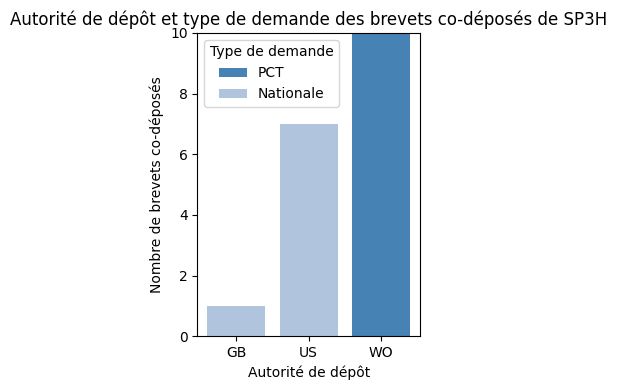

In [252]:
import pandas as pd

# Nettoyage des variables
df = coopp.copy()

df["appln_auth"] = (
    df["appln_auth"].astype(str).str.strip().str.upper()
)

df["appln_kind"] = (
    df["appln_kind"].astype(str).str.strip().str.upper()
)

# Mapping du type de demande
kind_map = {
    "W": "PCT",
    "A": "Nationale"
}

df["Type de demande"] = df["appln_kind"].map(kind_map)

# Table croisée
pivot = pd.crosstab(
    df["appln_auth"],
    df["Type de demande"]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(3,4))

plt.bar(
    pivot.index,
    pivot["PCT"],
    label="PCT",
    color="steelblue"
)

plt.bar(
    pivot.index,
    pivot["Nationale"],
    bottom=pivot["PCT"],
    label="Nationale",
    color="lightsteelblue"
)

plt.xlabel("Autorité de dépôt")
plt.ylabel("Nombre de brevets co-déposés")
plt.title("Autorité de dépôt et type de demande des brevets co-déposés de SP3H")
plt.legend(title="Type de demande")
plt.tight_layout()
plt.show()

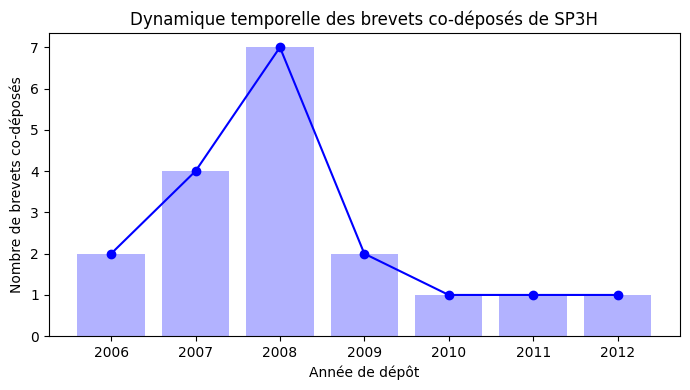

In [ ]:
filing_year_counts= filing_year_counts = coopp["appln_filing_year"].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(
    filing_year_counts.index,
    filing_year_counts.values, # type: ignore
    color="blue",
    alpha=0.3
)


plt.plot(
    filing_year_counts.index,
    filing_year_counts.values, # type: ignore
    marker='o',
    linestyle='-',
    color="blue"
)

plt.xlabel("Année de dépôt")
plt.ylabel("Nombre de brevets co-déposés")
plt.title("Dynamique temporelle des brevets co-déposés de SP3H")
plt.tight_layout()
plt.show()

In [280]:
coopp['granted']=(coopp["granted"].astype(str).str.strip().str.upper()
        .map({"Y": 1, "N": 0}))

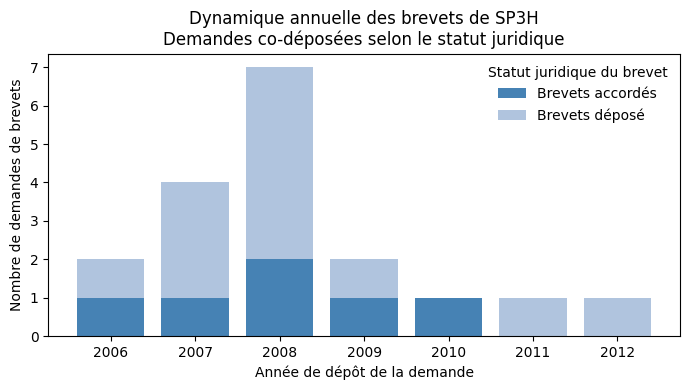

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Préparation des données (inchangée)


granted_by_year = (
    coopp
    .groupby("appln_filing_year")
    .agg(
        nb_demandes=("appln_filing_year", "count"),
        nb_granted=("granted", "sum")
    )
    .reset_index()
    .rename(columns={"appln_filing_year": "year"})
)

years = granted_by_year["year"]
nb_granted = granted_by_year["nb_granted"]
nb_not_granted = granted_by_year["nb_demandes"] - granted_by_year["nb_granted"]

# --- Plot
plt.figure(figsize=(7,4))

plt.bar(
    years,
    nb_granted,
    color="steelblue",
    label="Brevets accordés"
)

plt.bar(
    years,
    nb_not_granted,
    bottom=nb_granted,
    color="lightsteelblue",
    label="Brevets déposés"
)

plt.xlabel("Année de dépôt de la demande")
plt.ylabel("Nombre de demandes de brevets")
plt.title(
    "Dynamique annuelle des brevets de SP3H\n"
    "Demandes co-déposées selon le statut juridique"
)
plt.legend(
    title="Statut juridique du brevet",
    frameon=False
)

plt.tight_layout()
plt.show()

## 7. Identification des concurrents technologiques

In [ ]:
SELECT
    a.docdb_family_id,
    COUNT(DISTINCT p.person_id)    AS nb_concurrents,
    COUNT(DISTINCT a2.appln_id)    AS nb_applns_concurrents
FROM tls201_appln a
JOIN tls201_appln a2
    ON a.docdb_family_id = a2.docdb_family_id
JOIN tls207_pers_appln pa
    ON a2.appln_id = pa.appln_id
JOIN tls206_person p
    ON pa.person_id = p.person_id
WHERE a.docdb_family_id IN (
        SELECT DISTINCT a3.docdb_family_id
        FROM tls201_appln a3
        JOIN tls207_pers_appln pa2
            ON a3.appln_id = pa2.appln_id
        JOIN tls206_person p2
            ON pa2.person_id = p2.person_id
        WHERE p2.person_name LIKE 'SP3H%'
          AND pa2.applt_seq_nr > 0
    )
  AND pa.applt_seq_nr > 0
  AND p.person_name NOT LIKE 'SP3H%'
GROUP BY a.docdb_family_id
ORDER BY nb_concurrents DESC;


In [ ]:
concurrents=pd.read_csv("Data/Identification des concurrents technologiques.csv", sep=";")
concurrents

,docdb_family_id,nb_concurrents,nb_applns_concurrents
0,37890311,8,2
1,35266731,6,4
2,39267773,6,2
3,37663186,5,3
4,40120085,5,3
5,39264511,4,2
6,38820234,4,2
7,39186988,4,2
8,44454459,3,2
9,39267811,3,1


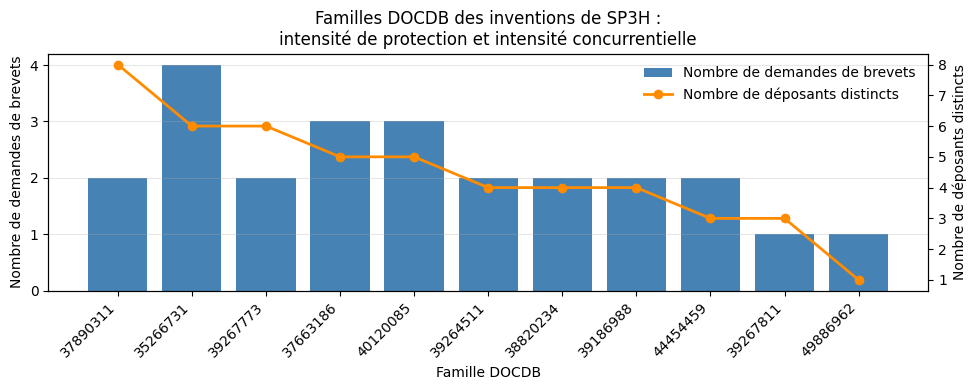

In [290]:
import matplotlib.pyplot as plt

famille_stats = concurrents.copy()

families = famille_stats["docdb_family_id"].astype(str)
x = range(len(families))

fig, ax1 = plt.subplots(figsize=(10, 4))

# -----------------------------
# Axe Y gauche : nb de demandes
# -----------------------------
ax1.bar(
    x,
    famille_stats["nb_applns_concurrents"],
    color="steelblue",
    label="Nombre de demandes de brevets"
)
ax1.set_ylabel("Nombre de demandes de brevets")
ax1.set_xlabel("Famille DOCDB")

# -----------------------------
# Axe Y droit : nb de concurrents
# -----------------------------
ax2 = ax1.twinx()
ax2.plot(
    x,
    famille_stats["nb_concurrents"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Nombre de déposants distincts"
)
ax2.set_ylabel("Nombre de déposants distincts")

# -----------------------------
# Axe X
# -----------------------------
ax1.set_xticks(x)
ax1.set_xticklabels(families, rotation=45, ha="right")

# -----------------------------
# Titre
# -----------------------------
plt.title(
    "Familles DOCDB des inventions de SP3H :\n"
    "intensité de protection et intensité concurrentielle"
)

# -----------------------------
# Légende combinée
# -----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
    frameon=False
)

ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Qualité / valeur des brevets 

### Citations reçues par SP3H

In [ ]:
SELECT c.cited_appln_id, COUNT(*) AS citations_received
FROM tls212_citation c
WHERE c.cited_appln_id IN (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H'
          AND pa.applt_seq_nr > 0
    )
GROUP BY c.cited_appln_id
ORDER BY citations_received DESC;


-- ==0

In [ ]:
SELECT c.cited_appln_id
FROM tls212_citation c
WHERE c.cited_appln_id IN (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H%'
          AND pa.applt_seq_nr > 0
    )

-- ==0

### Qualité par ipc

In [ ]:
SELECT ip.*
FROM tls201_appln a
JOIN tls209_appln_ipc ip ON a.appln_id = ip.appln_id
WHERE a.appln_id IN 
    (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H%'
          AND pa.applt_seq_nr > 0
    )

In [291]:
ipc=pd.read_csv("Data/Indicateurs ipc.csv",sep=";")
ipc

,appln_id,ipc_class_symbol,ipc_class_level,ipc_version,ipc_value,ipc_position,ipc_gener_auth
0,381150532,H01J 49/02,A,2006-01-01,I,F,FR
1,405962392,G01N 21/85,A,2006-01-01,I,F,BR
2,405962392,G01N 21/88,A,2006-01-01,I,L,BR
3,405962392,G01N 33/28,A,2006-01-01,I,L,BR
4,445532725,G01N 21/27,A,2006-01-01,I,L,US
...,...,...,...,...,...,...,...
367,374982845,F02D 41/26,A,2006-01-01,I,L,US
368,374982845,F02M 25/022,A,2006-01-01,I,L,US
369,374982845,G01N 21/3577,A,2014-01-01,I,L,US
370,374982845,G01N 21/359,A,2014-01-01,I,L,US


In [303]:
ipc["ipc_class_level"].value_counts()

ipc_class_level
A    371
C      1
Name: count, dtype: int64

### Présence dans grands offices (EPO, USPTO, JPO…)

In [ ]:
SELECT publn_auth, COUNT(*)
FROM tls211_pat_publn
WHERE appln_id IN (
        SELECT pa.appln_id
        FROM tls207_pers_appln pa
        JOIN tls206_person p ON pa.person_id = p.person_id
        WHERE p.person_name LIKE 'SP3H'
          AND pa.applt_seq_nr > 0
    )
GROUP BY publn_auth;

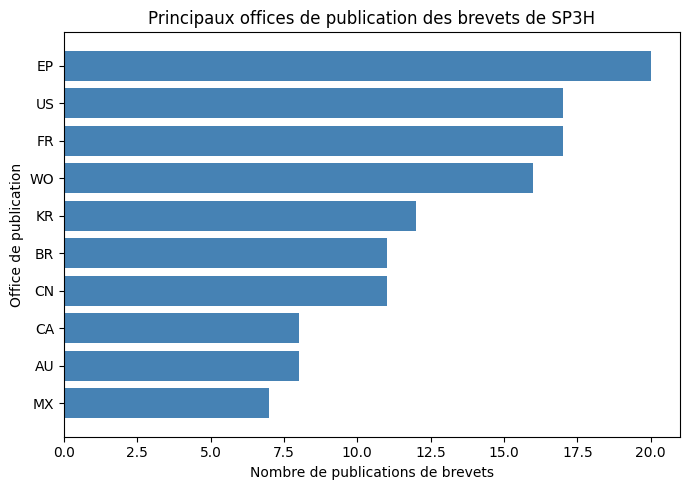

In [ ]:
grand_office=pd.read_csv("Data/Présence dans grands offices.csv", sep=";")

import matplotlib.pyplot as plt

# Tri décroissant
grand_office_sorted = grand_office.sort_values(
    by="nb_publications",
    ascending=False
).head(10)

plt.figure(figsize=(7,5))

plt.barh(
    grand_office_sorted["publn_auth"],
    grand_office_sorted["nb_publications"],
    color="steelblue"
)

plt.xlabel("Nombre de publications de brevets")
plt.ylabel("Office de publication")
plt.title(
    "Principaux offices de publication des brevets de SP3H"
)

plt.gca().invert_yaxis()  # plus grand en haut
plt.tight_layout()
plt.show()